# Урок 3.2. AdaBoost: бустинг через веса объектов

**Интерактивная версия:** `lessons/lesson_3_2/web/index.html`

1. AdaBoost с нуля в 20 строк.
2. Веса объектов и голоса учеников.
3. Теоретическая оценка ошибки на обучении.
4. Шум в метках.
5. Сверка с scikit-learn.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from gbcourse import datasets, AdaBoost, Mulberry32
from gbcourse.plotting import use_course_style, plot_decision_surface

use_course_style()

## 1. AdaBoost с нуля (пни из scikit-learn)

In [2]:
X, y = datasets.classification_2d(kind="circles", n=160, noise=0.15, seed=5)
ys = np.where(y == 1, 1, -1)


def adaboost(X, ys, M):
    n = len(ys)
    w = np.full(n, 1 / n)
    learners, alphas, errs = [], [], []
    for _ in range(M):
        stump = DecisionTreeClassifier(max_depth=1).fit(X, ys, sample_weight=w)
        pred = stump.predict(X)
        eps = w[pred != ys].sum() / w.sum()
        if eps >= 0.5:
            break
        alpha = 0.5 * np.log((1 - eps) / max(eps, 1e-10))
        w = w * np.exp(-alpha * ys * pred)
        w /= w.sum()
        learners.append(stump)
        alphas.append(alpha)
        errs.append(eps)
    return learners, np.array(alphas), np.array(errs)


learners, alphas, errs = adaboost(X, ys, 50)
F = sum(a * h.predict(X) for a, h in zip(alphas, learners))
print("точность на обучении:", np.mean(np.sign(F) == ys))
print("первые ε:", errs[:5].round(3))
print("первые α:", alphas[:5].round(3))

точность на обучении: 0.95
первые ε: [0.331 0.374 0.363 0.396 0.361]
первые α: [0.351 0.258 0.281 0.211 0.285]


## 2. Как меняется граница

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


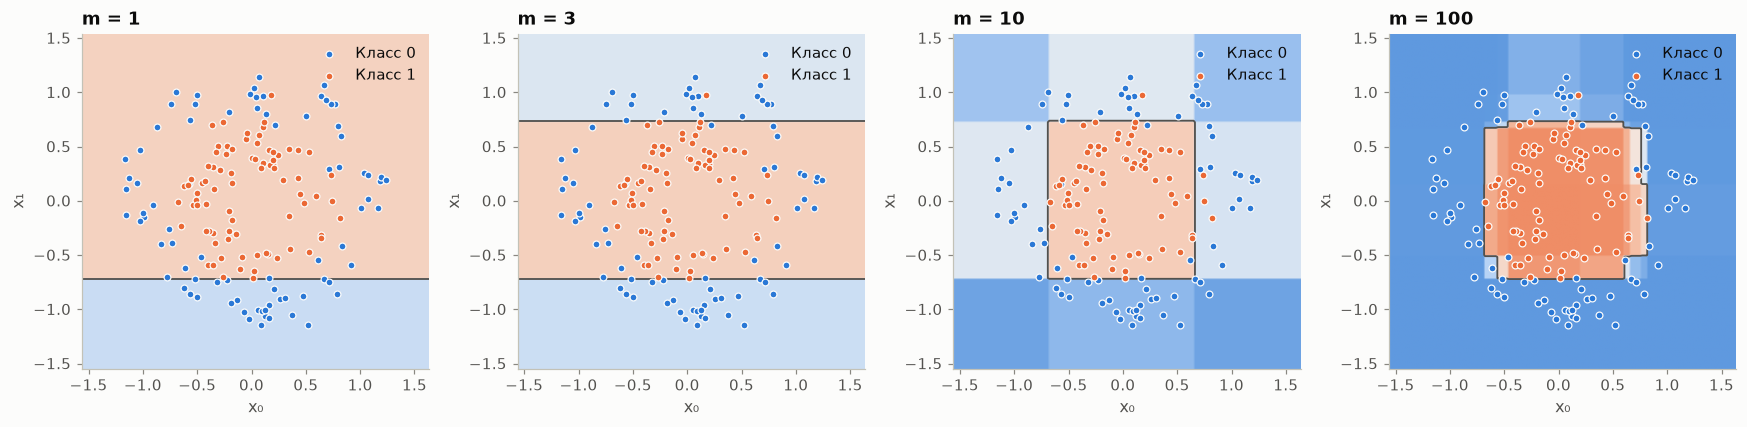

In [3]:
ada = AdaBoost(n_estimators=100).fit(X, y)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, m in zip(axes, (1, 3, 10, 100)):
    proba = lambda Z, m=m: 1 / (1 + np.exp(-2 * ada.decision_function(Z, n_trees=m)))
    plot_decision_surface(ax, proba, X, y, title=f"m = {m}")
plt.tight_layout()
plt.show()

## 3. Оценка ошибки на обучении

$\text{ошибка} \le \prod_m 2\sqrt{\varepsilon_m(1-\varepsilon_m)}$.

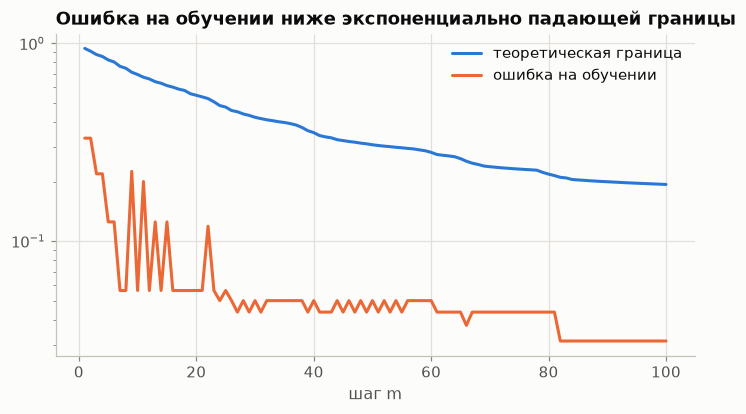

In [4]:
bound = np.cumprod(2 * np.sqrt(np.array(ada.errors_) * (1 - np.array(ada.errors_))))
train_err = [np.mean(ada.predict(X, n_trees=m) != y) for m in range(1, len(ada.trees_) + 1)]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.semilogy(range(1, len(bound) + 1), bound, label="теоретическая граница")
ax.semilogy(range(1, len(train_err) + 1), np.maximum(train_err, 1e-3), label="ошибка на обучении")
ax.set(xlabel="шаг m", title="Ошибка на обучении ниже экспоненциально падающей границы")
ax.legend()
plt.show()

## 4. Шум в метках: веса взрываются

In [5]:
rng = Mulberry32(99)
flip = np.array([rng.random() < 0.08 for _ in range(len(y))])
y_noisy = np.where(flip, 1 - y, y)
ada_n = AdaBoost(n_estimators=200).fit(X, y_noisy)
w_final = ada_n.weights_[-1]
print(f"испорчено меток: {flip.sum()} из {len(y)} ({flip.mean():.1%})")
print(f"доля суммарного веса на испорченных объектах в конце: {w_final[flip].sum():.1%}")

испорчено меток: 14 из 160 (8.8%)
доля суммарного веса на испорченных объектах в конце: 31.8%


## 5. Сверка с scikit-learn (SAMME)

In [6]:
sk = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100).fit(X, y)
print("совпадение прогнозов:", np.mean(sk.predict(X) == ada.predict(X)))
print("α у sklearn вдвое больше (без множителя ½):", np.allclose(sk.estimator_weights_[:5], 2 * np.array(ada.alphas_[:5])))

совпадение прогнозов: 1.0
α у sklearn вдвое больше (без множителя ½): True


## Упражнения

1. Проверьте численно: после обновления весов взвешенная ошибка текущего пня равна ровно 0.5.
2. Постройте точность на тесте AdaBoost при доле испорченных меток 0, 5, 10, 20%.
3. Добавьте в AdaBoost темп обучения ν (α ← ν·α). Влияет ли он на устойчивость к шуму? Проверьте на данных.

Решения: `python lessons/lesson_3_2/exercises/solutions.py`.